### Credit Risk Prediction

#### 1. Problem Statement
The objective of this project is to build a machine learning model that predicts whether a customer will default on a loan based on their financial, demographic, and loan-related information. This helps financial institutions assess credit risk and make informed lending decisions.

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#### 2. Data Understanding & Cleaning

In [40]:
df=pd.read_csv("Loan_default.csv")


In [41]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [42]:
df.shape

(255347, 18)

In [43]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [45]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [46]:
df["Default"].value_counts()
df["Default"].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

#### 3. Data Preprocessing

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
for col in df.select_dtypes(include="object").columns:
    print(col,df[col].unique())

LoanID ['I38PQUQS96' 'HPSK72WA7R' 'C1OZ6DPJ8Y' ... 'XQK1UUUNGP' 'JAO28CPL4H'
 'ZTH91CGL0B']
Education ["Bachelor's" "Master's" 'High School' 'PhD']
EmploymentType ['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
MaritalStatus ['Divorced' 'Married' 'Single']
HasMortgage ['Yes' 'No']
HasDependents ['Yes' 'No']
LoanPurpose ['Other' 'Auto' 'Business' 'Home' 'Education']
HasCoSigner ['Yes' 'No']


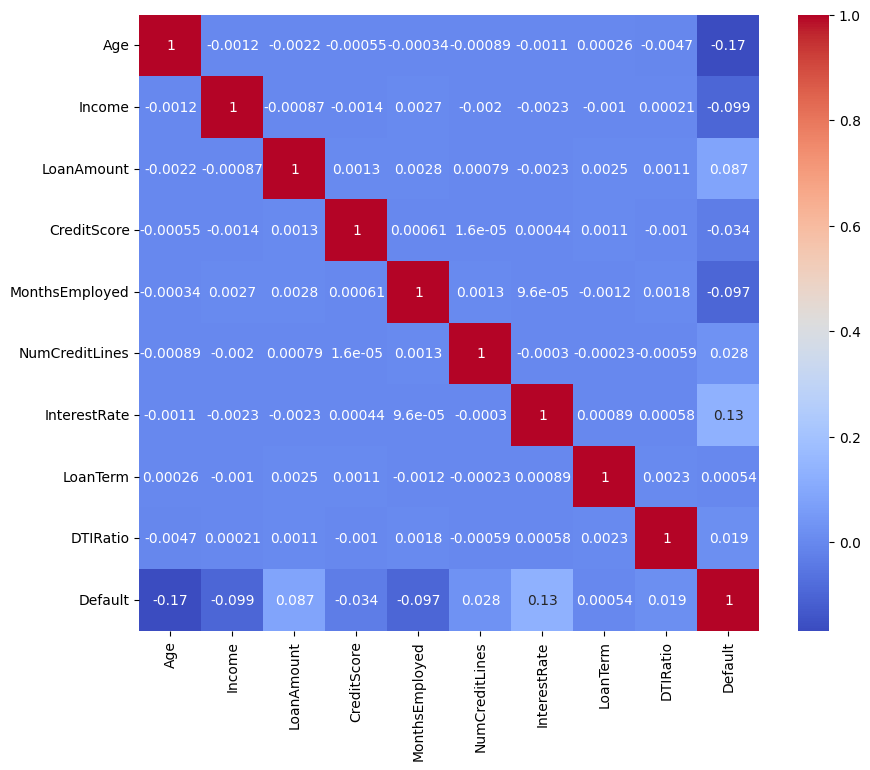

In [49]:
numeric_df=df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.show()

The dataset shows low linear correlation with the target, indicating that default risk is likely influenced by complex, non-linear relationships. Therefore, tree-based models like Random Forest or XGBoost may perform better.

#### 4. Exploratory Data Analysis (EDA)

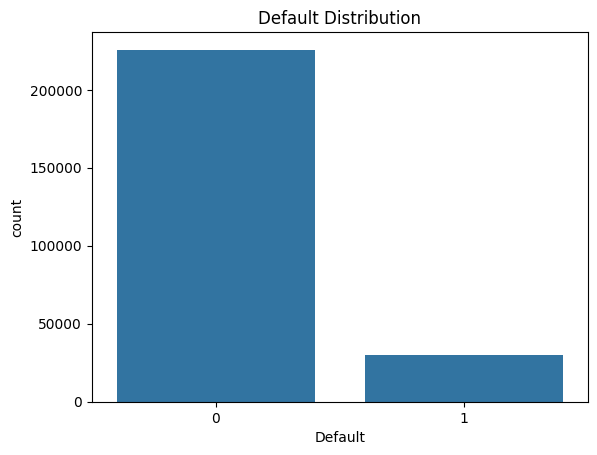

In [50]:
sns.countplot(data=df,x="Default")
plt.title("Default Distribution")
plt.show()

Default Distribution shows data imbalance.

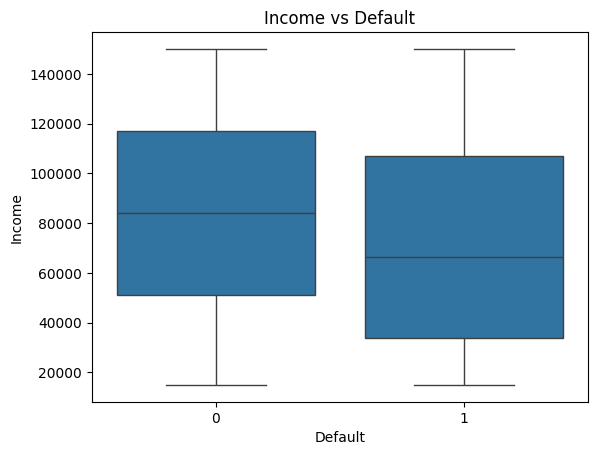

In [51]:
sns.boxplot(data=df,x="Default",y="Income")
plt.title("Income vs Default")
plt.show()

Customers with lower income show a higher likelihood of default.

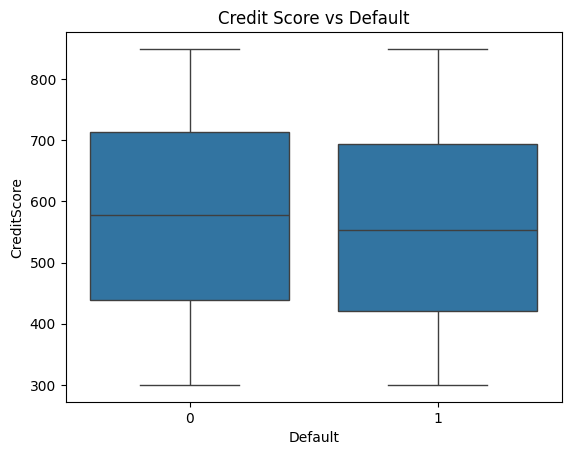

In [52]:
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Default")
plt.show()

Customers with lower credit scores exhibit a higher probability of default.

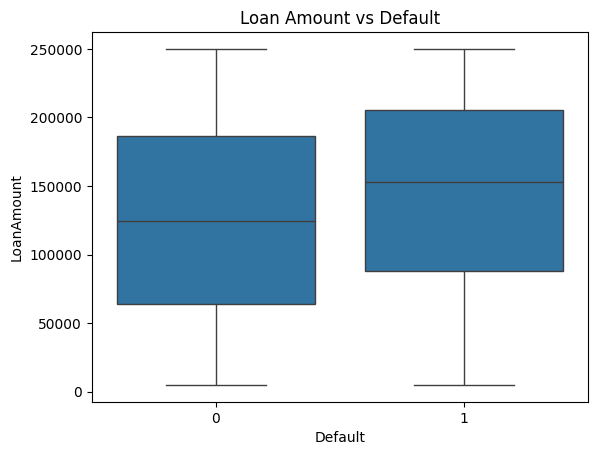

In [53]:
sns.boxplot(x='Default', y='LoanAmount', data=df)
plt.title("Loan Amount vs Default")
plt.show()

Bigger loans leads to higher risk

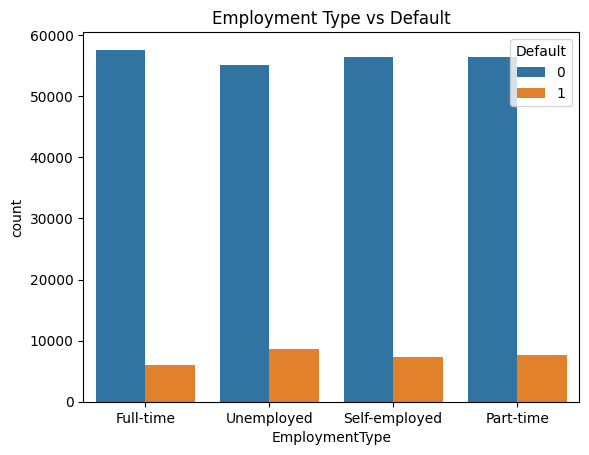

In [54]:
sns.countplot(x='EmploymentType', hue='Default', data=df)
plt.title("Employment Type vs Default")
plt.show()

Unemployed leads to high default

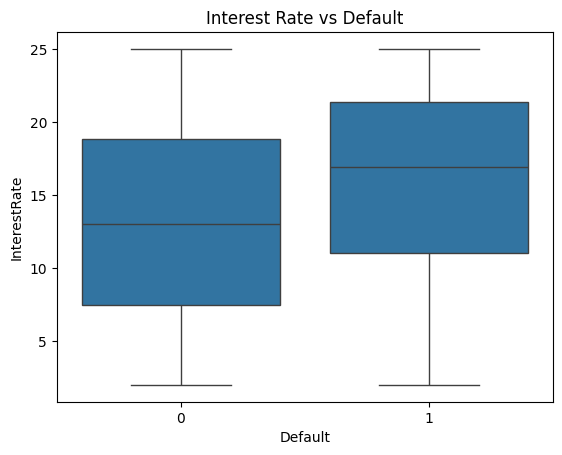

In [76]:
sns.boxplot(x='Default', y='InterestRate', data=df)
plt.title("Interest Rate vs Default")
plt.show()

Higher interest leads to higher risk

#### 5. Feature Engineering & Encoding

In [55]:
df=df.drop("LoanID",axis=1)

In [56]:
binary_cols=["HasMortgage","HasDependents","HasCoSigner"]
for col in binary_cols:
    df[col]=df[col].map({"Yes":1,"No":0})

In [57]:
df=pd.get_dummies(df,drop_first=True)

In [58]:
X=df.drop("Default",axis=1)
y=df["Default"]

####  6. Model Building & Model Evaluation

##### 1) Logistic Regression

In [59]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [60]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

/opt/miniconda3/envs/ds/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
y_pred=model.predict(X_test)

In [62]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[44988   151]
 [ 5717   214]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.59      0.04      0.07      5931

    accuracy                           0.89     51070
   macro avg       0.74      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070



Although accuracy is high (~89%), the model performs poorly on the minority class with very low recall (~4%), making it unsuitable for credit risk prediction.

In [63]:
# Handling Imbalance Data
model=LogisticRegression(max_iter=1000,class_weight="balanced")
model.fit(X_train,y_train)

/opt/miniconda3/envs/ds/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [64]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[30464 14675]
 [ 1883  4048]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.68      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.68      0.73     51070



After handling class imbalance, recall improved significantly from 4% to 68%, making the model more suitable for identifying high-risk customers, even though precision decreased.

##### 2) Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_rf=rf.predict(X_test)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[45098    41]
 [ 5841    90]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.69      0.02      0.03      5931

    accuracy                           0.88     51070
   macro avg       0.79      0.51      0.48     51070
weighted avg       0.86      0.88      0.83     51070



In [67]:
# Adjusting Threshold
y_probs=rf.predict_proba(X_test)[:,1]
y_pred_new=(y_probs>0.3).astype(int)
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[43898  1241]
 [ 4955   976]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.93     45139
           1       0.44      0.16      0.24      5931

    accuracy                           0.88     51070
   macro avg       0.67      0.57      0.59     51070
weighted avg       0.85      0.88      0.85     51070



##### 3) XGBoost

In [68]:
import xgboost
print(xgboost.__version__)

3.2.0


In [69]:
from xgboost import XGBClassifier
xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])),
    random_state=42
)
xgb.fit(X_train,y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [70]:
# Saving the model
import joblib
joblib.dump(xgb,"model.pkl")

['model.pkl']

In [71]:
# Adjusting Threshold
y_probs_xgb=xgb.predict_proba(X_test)[:,1]
y_pred_xgb=(y_probs_xgb>0.3).astype(int)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[18698 26441]
 [  741  5190]]
              precision    recall  f1-score   support

           0       0.96      0.41      0.58     45139
           1       0.16      0.88      0.28      5931

    accuracy                           0.47     51070
   macro avg       0.56      0.64      0.43     51070
weighted avg       0.87      0.47      0.54     51070



In [72]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_temp = (y_probs_xgb > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_temp))
    print(classification_report(y_test, y_pred_temp))


Threshold: 0.3
[[18698 26441]
 [  741  5190]]
              precision    recall  f1-score   support

           0       0.96      0.41      0.58     45139
           1       0.16      0.88      0.28      5931

    accuracy                           0.47     51070
   macro avg       0.56      0.64      0.43     51070
weighted avg       0.87      0.47      0.54     51070


Threshold: 0.4
[[26230 18909]
 [ 1320  4611]]
              precision    recall  f1-score   support

           0       0.95      0.58      0.72     45139
           1       0.20      0.78      0.31      5931

    accuracy                           0.60     51070
   macro avg       0.57      0.68      0.52     51070
weighted avg       0.86      0.60      0.67     51070


Threshold: 0.5
[[32575 12564]
 [ 2108  3823]]
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     45139
           1       0.23      0.64      0.34      5931

    accuracy                           0.

In [73]:
# Adjusting Threshold
y_probs_xgb=xgb.predict_proba(X_test)[:,1]
y_pred_xgb=(y_probs_xgb>0.4).astype(int)
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[26230 18909]
 [ 1320  4611]]
              precision    recall  f1-score   support

           0       0.95      0.58      0.72     45139
           1       0.20      0.78      0.31      5931

    accuracy                           0.60     51070
   macro avg       0.57      0.68      0.52     51070
weighted avg       0.86      0.60      0.67     51070



At threshold 0.4, the model effectively identifies high-risk customers while reducing unnecessary rejection of low-risk applicants compared to more aggressive thresholds.

#### 7. Model Comparison & Selection
XGboost with a threshold of 0.4 as it provides a good balance between recall and precision, ensuring most defaulters are identified while limiting false positives.

#### 8. Model Interpretation (Feature Importance)

In [74]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance.head(10)

,Feature,Importance
0,Age,0.135018
6,InterestRate,0.072355
1,Income,0.061595
11,HasCoSigner,0.061354
10,HasDependents,0.059097
17,EmploymentType_Unemployed,0.051638
4,MonthsEmployed,0.050602
2,LoanAmount,0.046375
16,EmploymentType_Self-employed,0.042171
18,MaritalStatus_Married,0.038155


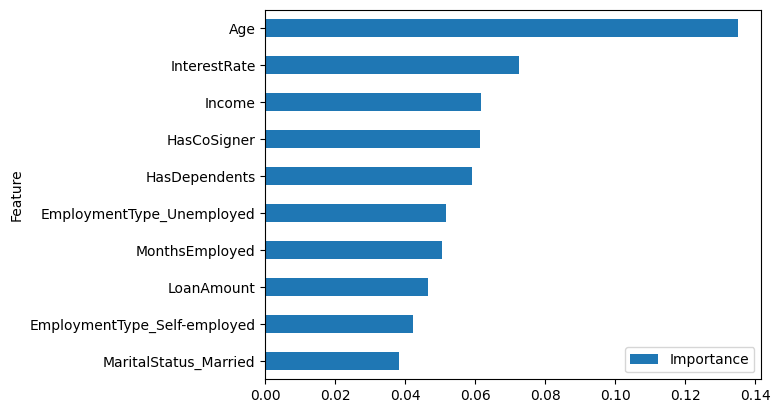

In [75]:
feature_importance.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.gca().invert_yaxis()
plt.show()

####  9. Business Insights
The model identified age, interest rate, income, and employment status as key drivers of default. This aligns with real-world credit risk logic, where financial stability and repayment burden play a crucial role.

#### 10. Conclusion:
This project developed a credit risk prediction model using machine learning to identify potential loan defaulters. After handling class imbalance and optimizing the classification threshold, the XGBoost model achieved strong recall, enabling effective identification of high-risk customers. Feature importance analysis revealed that factors such as age, income, interest rate, and employment status significantly influence default risk. This solution can help financial institutions minimize losses and improve lending decisions.

#### 11. Deployment:
Live Demo : [Open App](https://credit-risk-prediction-my3zg53cmtghuadvkccesa.streamlit.app/)